In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')


In [8]:
df = pd.read_csv("data/final_data.csv")

variables = [
    "cash_demand",
    "tax_burden",
    "interest_rate_avg_q",
    "log_gdp_per_capita"
]

if "log_gdp_per_capita" not in df.columns:
    df["log_gdp_per_capita"] = np.log(df["gdp_per_capita"])

print("=" * 60)
print("1. DESCRIPTIVE STATISTICS")
print("=" * 60)
print(df[variables].describe())
print("\n")

print("=" * 60)
print("2. STATIONARITY TESTS")
print("=" * 60)

def stationarity_tests(series, name):
    """Run ADF and KPSS tests on a series."""
    series_clean = series.dropna()
    
    adf_result = adfuller(series_clean, autolag='AIC')
    adf_stat, adf_p = adf_result[0], adf_result[1]
    
    kpss_result = kpss(series_clean, regression='c', nlags='auto')
    kpss_stat, kpss_p = kpss_result[0], kpss_result[1]
    
    print(f"\n{name}:")
    print(f"  ADF statistic: {adf_stat:.4f}, p-value: {adf_p:.4f}")
    print(f"    → {'Stationary' if adf_p < 0.05 else 'Non-stationary'} at 5% level")
    print(f"  KPSS statistic: {kpss_stat:.4f}, p-value: {kpss_p:.4f}")
    print(f"    → {'Stationary' if kpss_p > 0.05 else 'Non-stationary'} at 5% level")
    
    return {"variable": name, "ADF_stat": adf_stat, "ADF_p": adf_p, 
            "KPSS_stat": kpss_stat, "KPSS_p": kpss_p}

stationarity_results = []
for var in variables:
    result = stationarity_tests(df[var], var)
    stationarity_results.append(result)

print("\n")

print("=" * 60)
print("3. CORRELATION MATRIX")
print("=" * 60)
print(df[variables].corr().round(3))
print("\n")

print("=" * 60)
print("4. VARIANCE INFLATION FACTORS (VIF)")
print("=" * 60)

regressors = ["tax_burden", "interest_rate_avg_q", "log_gdp_per_capita"]
X_vif = df[regressors].dropna()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)
print("\nInterpretation: VIF > 5 suggests moderate multicollinearity; VIF > 10 is problematic")
print("\n")

print("=" * 60)
print("5. PRELIMINARY OLS ESTIMATION")
print("=" * 60)

model_df = df[["cash_demand"] + regressors].dropna()
y = model_df["cash_demand"]
X = sm.add_constant(model_df[regressors])

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())
print("\n")

print("=" * 60)
print("6. RESIDUAL DIAGNOSTICS")
print("=" * 60)

resid = ols_model.resid

print("\n6a. Ljung-Box Test (H0: no autocorrelation):")
lb_test = acorr_ljungbox(resid, lags=[1, 4, 8], return_df=True)
print(lb_test)

print("\n6b. ARCH-LM Test (H0: no ARCH effects):")
arch_test = het_arch(resid, nlags=4)
print(f"  LM statistic: {arch_test[0]:.4f}")
print(f"  LM p-value: {arch_test[1]:.4f}")
print(f"  F statistic: {arch_test[2]:.4f}")
print(f"  F p-value: {arch_test[3]:.4f}")

print("\n6c. Jarque-Bera Test (H0: residuals are normal):")
jb_stat, jb_p = stats.jarque_bera(resid)
print(f"  JB statistic: {jb_stat:.4f}, p-value: {jb_p:.4f}")

print(f"\n6d. Durbin-Watson statistic: {sm.stats.stattools.durbin_watson(resid):.4f}")
print("  (Values near 2 suggest no autocorrelation; <1.5 or >2.5 suggests problems)")
print("\n")

print("=" * 60)
print("7. QUICK SCATTER CHECK (values for plotting)")
print("=" * 60)
print("\nCorrelation between cash_demand and tax_burden:", 
      df["cash_demand"].corr(df["tax_burden"]).round(4))
print("Correlation between cash_demand and interest_rate_avg_q:", 
      df["cash_demand"].corr(df["interest_rate_avg_q"]).round(4))
print("\n")

print("=" * 60)
print("8. POTENTIAL STRUCTURAL BREAK POINTS")
print("=" * 60)
print("\nKey dates to consider for break dummies:")
print("  - 2014 Q1: Crimea annexation, initial conflict")
print("  - 2020 Q1: COVID-19 pandemic")
print("  - 2022 Q1: Full-scale invasion (if your data extends there)")
print("\nObservation counts by year:")
print(df["year_quarter"].str[:4].value_counts().sort_index())


1. DESCRIPTIVE STATISTICS
       cash_demand  tax_burden  interest_rate_avg_q  log_gdp_per_capita
count    48.000000   48.000000            48.000000           48.000000
mean      0.280378   26.416598            12.284907           10.337023
std       0.014779    2.812718             5.937749            0.047509
min       0.250060   19.756105             6.000000           10.237799
25%       0.274429   24.536441             7.669350           10.300941
50%       0.278789   26.083750            10.154167           10.347467
75%       0.286742   28.387112            16.178967           10.368912
max       0.322104   33.684943            30.000000           10.422441


2. STATIONARITY TESTS

cash_demand:
  ADF statistic: -3.3851, p-value: 0.0115
    → Stationary at 5% level
  KPSS statistic: 0.3344, p-value: 0.1000
    → Stationary at 5% level

tax_burden:
  ADF statistic: -1.9384, p-value: 0.3142
    → Non-stationary at 5% level
  KPSS statistic: 0.2573, p-value: 0.1000
    → Stationary

In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("data/final_data.csv")
df["log_gdp_per_capita"] = np.log(df["gdp_per_capita"])

print("=" * 60)
print("1. STATIONARITY OF FIRST-DIFFERENCED VARIABLES")
print("=" * 60)

variables_to_diff = ["tax_burden", "interest_rate_avg_q", "log_gdp_per_capita"]

for var in variables_to_diff:
    diff_series = df[var].diff().dropna()
    adf_result = adfuller(diff_series, autolag='AIC')
    print(f"\nΔ{var}:")
    print(f"  ADF statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}")
    print(f"  → {'Stationary' if adf_result[1] < 0.05 else 'Still non-stationary'}")

print("\n")
print("=" * 60)
print("2. COINTEGRATION TEST")
print("=" * 60)

y = df["cash_demand"].dropna()
X = df[["tax_burden", "interest_rate_avg_q", "log_gdp_per_capita"]].dropna()

common_idx = y.index.intersection(X.index)
y = y.loc[common_idx]
X = X.loc[common_idx]

X_const = sm.add_constant(X)
coint_reg = sm.OLS(y, X_const).fit()
resid = coint_reg.resid

adf_resid = adfuller(resid, autolag='AIC')
print(f"\nResidual ADF statistic: {adf_resid[0]:.4f}")
print(f"Residual ADF p-value: {adf_resid[1]:.4f}")
print(f"Critical values: {adf_resid[4]}")
print("\nInterpretation: If p < 0.05, variables are cointegrated")

print("\n")
print("=" * 60)
print("3. MODEL WITH 2014 BREAK DUMMY + HAC STANDARD ERRORS")
print("=" * 60)

df["year"] = df["year_quarter"].str[:4].astype(int)
df["post_2014"] = (df["year"] >= 2014).astype(int)

df["quarter"] = df["year_quarter"].str[-1].astype(int)
df["Q2"] = (df["quarter"] == 2).astype(float)
df["Q3"] = (df["quarter"] == 3).astype(float)
df["Q4"] = (df["quarter"] == 4).astype(float)

regressors = ["tax_burden", "interest_rate_avg_q", "log_gdp_per_capita", 
              "post_2014", "Q2", "Q3", "Q4"]

model_df = df[["cash_demand"] + regressors].copy()
model_df = model_df.dropna()

for col in model_df.columns:
    model_df[col] = model_df[col].astype(float)

y = model_df["cash_demand"]
X = model_df[regressors]
X = sm.add_constant(X)

model_hac = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
print(model_hac.summary())

print("\nResidual Ljung-Box after HAC model:")
lb_test = acorr_ljungbox(model_hac.resid, lags=[1, 4, 8], return_df=True)
print(lb_test)

print(f"\nDurbin-Watson: {sm.stats.stattools.durbin_watson(model_hac.resid):.4f}")

print("\n")
print("=" * 60)
print("4. AUTOREGRESSIVE DISTRIBUTED LAG MODEL (ADL)")
print("=" * 60)

df["cash_demand_lag1"] = df["cash_demand"].shift(1)

regressors_adl = ["cash_demand_lag1", "tax_burden", "interest_rate_avg_q", 
                  "log_gdp_per_capita", "post_2014"]

model_df_adl = df[["cash_demand"] + regressors_adl].copy()
model_df_adl = model_df_adl.dropna()

for col in model_df_adl.columns:
    model_df_adl[col] = model_df_adl[col].astype(float)

y_adl = model_df_adl["cash_demand"]
X_adl = model_df_adl[regressors_adl]
X_adl = sm.add_constant(X_adl)

model_adl = sm.OLS(y_adl, X_adl).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
print(model_adl.summary())

print("\nResidual Ljung-Box after ADL model:")
lb_adl = acorr_ljungbox(model_adl.resid, lags=[1, 4, 8], return_df=True)
print(lb_adl)

print(f"\nDurbin-Watson (ADL): {sm.stats.stattools.durbin_watson(model_adl.resid):.4f}")

print("\n")
print("=" * 60)
print("5. MODEL COMPARISON")
print("=" * 60)
print(f"\nBasic OLS:           R² = 0.174, DW = 0.645")
print(f"With break + HAC:    R² = {model_hac.rsquared:.3f}, DW = {sm.stats.stattools.durbin_watson(model_hac.resid):.3f}, AIC = {model_hac.aic:.1f}")
print(f"ADL model:           R² = {model_adl.rsquared:.3f}, DW = {sm.stats.stattools.durbin_watson(model_adl.resid):.3f}, AIC = {model_adl.aic:.1f}")

1. STATIONARITY OF FIRST-DIFFERENCED VARIABLES

Δtax_burden:
  ADF statistic: -2.5099, p-value: 0.1131
  → Still non-stationary

Δinterest_rate_avg_q:
  ADF statistic: -3.5850, p-value: 0.0061
  → Stationary

Δlog_gdp_per_capita:
  ADF statistic: -7.3636, p-value: 0.0000
  → Stationary


2. COINTEGRATION TEST

Residual ADF statistic: -3.8146
Residual ADF p-value: 0.0028
Critical values: {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}

Interpretation: If p < 0.05, variables are cointegrated


3. MODEL WITH 2014 BREAK DUMMY + HAC STANDARD ERRORS
                            OLS Regression Results                            
Dep. Variable:            cash_demand   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     2.421
Date:                Fri, 01 May 2026   Prob (F-statistic):     

In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("data/final_data.csv")
df["log_gdp_per_capita"] = np.log(df["gdp_per_capita"])
df["cash_demand_lag1"] = df["cash_demand"].shift(1)
df["year"] = df["year_quarter"].str[:4].astype(int)
df["post_2014"] = (df["year"] >= 2014).astype(float)

print("=" * 60)
print("1. PARSIMONIOUS ADL MODEL")
print("=" * 60)

regressors_v1 = ["cash_demand_lag1", "tax_burden", "log_gdp_per_capita"]

model_df = df[["cash_demand"] + regressors_v1].dropna()
for col in model_df.columns:
    model_df[col] = model_df[col].astype(float)

y = model_df["cash_demand"]
X = sm.add_constant(model_df[regressors_v1])

model_v1 = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
print(model_v1.summary())

print(f"\nDurbin-Watson: {sm.stats.stattools.durbin_watson(model_v1.resid):.4f}")

print("\n")
print("=" * 60)
print("2. LONG-RUN (EQUILIBRIUM) COEFFICIENTS")
print("=" * 60)

rho = model_v1.params["cash_demand_lag1"]
beta_tax = model_v1.params["tax_burden"]
beta_gdp = model_v1.params["log_gdp_per_capita"]

lr_tax = beta_tax / (1 - rho)
lr_gdp = beta_gdp / (1 - rho)

print(f"Persistence parameter (ρ): {rho:.4f}")
print(f"\nShort-run effect of tax_burden: {beta_tax:.6f}")
print(f"Long-run effect of tax_burden:  {lr_tax:.6f}")
print(f"\nShort-run effect of log_gdp_pc: {beta_gdp:.6f}")
print(f"Long-run effect of log_gdp_pc:  {lr_gdp:.6f}")

print("\nInterpretation:")
print(f"  A 1 pp increase in tax burden leads to a {lr_tax*100:.4f} pp")
print(f"  change in cash demand ratio in the long run.")

print("\n")
print("=" * 60)
print("3. TEST ALTERNATIVE TAX MEASURES")
print("=" * 60)

df["direct_tax_lag1"] = df["direct_tax_share"].shift(1)

for tax_var in ["tax_burden", "direct_tax_share", "fiscal_freedom"]:
    if tax_var in df.columns:
        temp_regs = ["cash_demand_lag1", tax_var, "log_gdp_per_capita"]
        temp_df = df[["cash_demand"] + temp_regs].dropna()
        for col in temp_df.columns:
            temp_df[col] = temp_df[col].astype(float)
        
        y_temp = temp_df["cash_demand"]
        X_temp = sm.add_constant(temp_df[temp_regs])
        
        m = sm.OLS(y_temp, X_temp).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
        
        print(f"\n{tax_var}:")
        print(f"  Coefficient: {m.params[tax_var]:.6f}")
        print(f"  t-stat: {m.tvalues[tax_var]:.3f}, p-value: {m.pvalues[tax_var]:.4f}")
        print(f"  R²: {m.rsquared:.3f}")
print("\n")
print("=" * 60)
print("4. ERROR CORRECTION MODEL (ECM)")
print("=" * 60)

y_levels = df["cash_demand"].dropna()
X_levels = df[["tax_burden", "log_gdp_per_capita"]].dropna()
common_idx = y_levels.index.intersection(X_levels.index)
y_levels = y_levels.loc[common_idx]
X_levels = X_levels.loc[common_idx]

X_levels_const = sm.add_constant(X_levels)
eq_model = sm.OLS(y_levels, X_levels_const).fit()
df["eq_residual"] = np.nan
df.loc[common_idx, "eq_residual"] = eq_model.resid
df["eq_residual_lag1"] = df["eq_residual"].shift(1)

df["d_cash_demand"] = df["cash_demand"].diff()
df["d_tax_burden"] = df["tax_burden"].diff()
df["d_log_gdp_pc"] = df["log_gdp_per_capita"].diff()

ecm_vars = ["eq_residual_lag1", "d_tax_burden", "d_log_gdp_pc"]
ecm_df = df[["d_cash_demand"] + ecm_vars].dropna()
for col in ecm_df.columns:
    ecm_df[col] = ecm_df[col].astype(float)

y_ecm = ecm_df["d_cash_demand"]
X_ecm = sm.add_constant(ecm_df[ecm_vars])

ecm_model = sm.OLS(y_ecm, X_ecm).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
print(ecm_model.summary())

print(f"\nError correction coefficient: {ecm_model.params['eq_residual_lag1']:.4f}")
print("(Should be negative and significant for valid ECM)")

print(f"\nDurbin-Watson: {sm.stats.stattools.durbin_watson(ecm_model.resid):.4f}")

print("\n")
print("=" * 60)
print("5. FINAL MODEL DIAGNOSTICS (Parsimonious ADL)")
print("=" * 60)

resid = model_v1.resid

bp_test = het_breuschpagan(resid, X)
print(f"\nBreusch-Pagan test:")
print(f"  LM statistic: {bp_test[0]:.4f}, p-value: {bp_test[1]:.4f}")

print(f"\nLjung-Box test:")
print(acorr_ljungbox(resid, lags=[1, 4, 8], return_df=True))

jb_stat, jb_p = stats.jarque_bera(resid)
print(f"\nJarque-Bera: {jb_stat:.4f}, p-value: {jb_p:.4f}")


1. PARSIMONIOUS ADL MODEL
                            OLS Regression Results                            
Dep. Variable:            cash_demand   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     11.45
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.20e-05
Time:                        10:17:37   Log-Likelihood:                 149.82
No. Observations:                  47   AIC:                            -291.6
Df Residuals:                      43   BIC:                            -284.2
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const     

SHADOW ECONOMY ESTIMATION

Minimum tax burden in sample: 19.76%
Maximum tax burden in sample: 33.68%
Mean tax burden: 26.42%

CONVERSION TO SHADOW ECONOMY SIZE

Long-run tax coefficient: -0.002313

------------------------------------------------------------
SHADOW ECONOMY ESTIMATES BY PERIOD
------------------------------------------------------------
year_quarter  tax_burden  shadow_economy_method1  shadow_economy_method2
      2010Q2       25.65                    0.66                    1.36
      2010Q3       23.71                    3.57                    0.91
      2010Q4       25.29                   -0.84                    1.28
      2011Q1       28.25                   -1.16                    1.96
      2011Q2       26.00                   -0.60                    1.44
      2011Q3       24.08                    0.64                    1.00
      2011Q4       25.44                   -3.11                    1.32
      2012Q1       28.58                   -4.18             

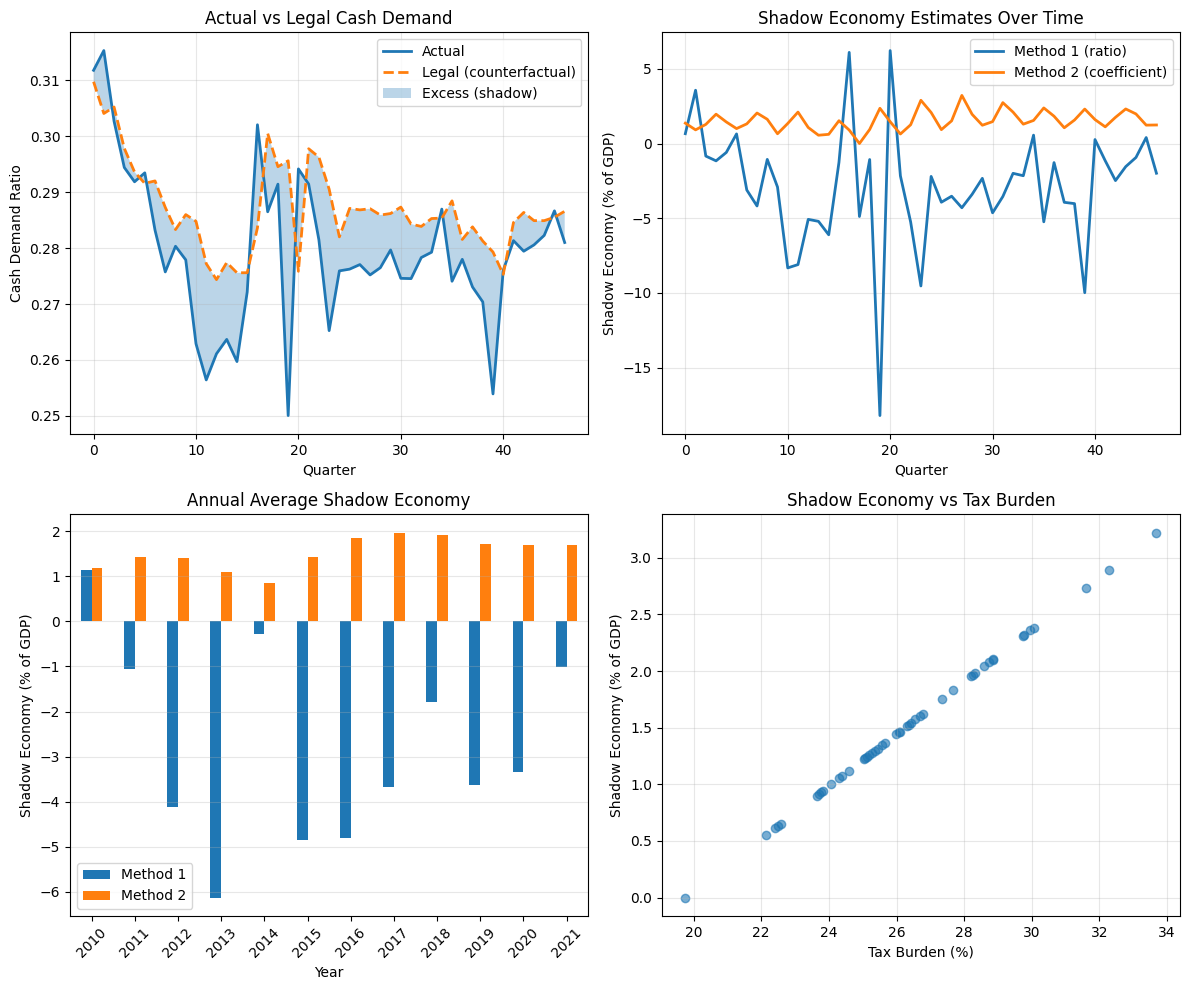


Visualization saved as 'shadow_economy_estimates_cda.png'
Results saved to 'shadow_economy_results.csv'


In [11]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("data/final_data.csv")
df["log_gdp_per_capita"] = np.log(df["gdp_per_capita"])
df["cash_demand_lag1"] = df["cash_demand"].shift(1)

regressors = ["cash_demand_lag1", "tax_burden", "log_gdp_per_capita"]
model_df = df[["cash_demand", "year_quarter"] + regressors].dropna()
for col in model_df.columns:
    if col != "year_quarter":
        model_df[col] = model_df[col].astype(float)

y = model_df["cash_demand"]
X = sm.add_constant(model_df[regressors])

final_model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

print("=" * 60)
print("SHADOW ECONOMY ESTIMATION")
print("=" * 60)

min_tax = df["tax_burden"].min()
print(f"\nMinimum tax burden in sample: {min_tax:.2f}%")
print(f"Maximum tax burden in sample: {df['tax_burden'].max():.2f}%")
print(f"Mean tax burden: {df['tax_burden'].mean():.2f}%")

X_legal = model_df[regressors].copy()
X_legal["tax_burden"] = min_tax

X_legal = sm.add_constant(X_legal, has_constant="add")
X_legal = X_legal[X.columns]

legal_cash_demand = final_model.predict(X_legal)
actual_cash_demand = model_df["cash_demand"].values

excess_cash = actual_cash_demand - legal_cash_demand

print("\n" + "=" * 60)
print("CONVERSION TO SHADOW ECONOMY SIZE")
print("=" * 60)

shadow_pct_simple = (excess_cash / actual_cash_demand) * 100

beta_tax = final_model.params["tax_burden"]
rho = final_model.params["cash_demand_lag1"]
lr_tax = beta_tax / (1 - rho)

print(f"\nLong-run tax coefficient: {lr_tax:.6f}")

tax_gap = model_df["tax_burden"].values - min_tax
shadow_economy_pct = np.abs(lr_tax) * tax_gap * 100

results = pd.DataFrame({
    "year_quarter": model_df["year_quarter"].values,
    "actual_cash_demand": actual_cash_demand,
    "legal_cash_demand": legal_cash_demand,
    "excess_cash_ratio": excess_cash,
    "shadow_economy_method1": shadow_pct_simple,
    "shadow_economy_method2": shadow_economy_pct,
    "tax_burden": model_df["tax_burden"].values
})

print("\n" + "-" * 60)
print("SHADOW ECONOMY ESTIMATES BY PERIOD")
print("-" * 60)
print(results[["year_quarter", "tax_burden", "shadow_economy_method1", 
               "shadow_economy_method2"]].round(2).to_string(index=False))

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

print("\nMethod 1 (Excess cash ratio):")
print(f"  Mean shadow economy: {results['shadow_economy_method1'].mean():.2f}%")
print(f"  Min: {results['shadow_economy_method1'].min():.2f}%")
print(f"  Max: {results['shadow_economy_method1'].max():.2f}%")

print("\nMethod 2 (Coefficient-based):")
print(f"  Mean shadow economy: {results['shadow_economy_method2'].mean():.2f}%")
print(f"  Min: {results['shadow_economy_method2'].min():.2f}%")
print(f"  Max: {results['shadow_economy_method2'].max():.2f}%")

results["year"] = results["year_quarter"].str[:4]
annual = results.groupby("year")[["shadow_economy_method1", "shadow_economy_method2"]].mean()
print("\n" + "-" * 60)
print("ANNUAL AVERAGES")
print("-" * 60)
print(annual.round(2))

print("\n" + "=" * 60)
print("GENERATING VISUALIZATION...")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = axes[0, 0]
ax1.plot(range(len(results)), results["actual_cash_demand"], 
         label="Actual", linewidth=2)
ax1.plot(range(len(results)), results["legal_cash_demand"], 
         label="Legal (counterfactual)", linewidth=2, linestyle="--")
ax1.fill_between(range(len(results)), results["legal_cash_demand"], 
                  results["actual_cash_demand"], alpha=0.3, label="Excess (shadow)")
ax1.set_xlabel("Quarter")
ax1.set_ylabel("Cash Demand Ratio")
ax1.set_title("Actual vs Legal Cash Demand")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(range(len(results)), results["shadow_economy_method1"], 
         label="Method 1 (ratio)", linewidth=2)
ax2.plot(range(len(results)), results["shadow_economy_method2"], 
         label="Method 2 (coefficient)", linewidth=2)
ax2.set_xlabel("Quarter")
ax2.set_ylabel("Shadow Economy (% of GDP)")
ax2.set_title("Shadow Economy Estimates Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
annual.plot(kind="bar", ax=ax3)
ax3.set_xlabel("Year")
ax3.set_ylabel("Shadow Economy (% of GDP)")
ax3.set_title("Annual Average Shadow Economy")
ax3.legend(["Method 1", "Method 2"])
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

ax4 = axes[1, 1]
ax4.scatter(results["tax_burden"], results["shadow_economy_method2"], alpha=0.6)
ax4.set_xlabel("Tax Burden (%)")
ax4.set_ylabel("Shadow Economy (% of GDP)")
ax4.set_title("Shadow Economy vs Tax Burden")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/shadow_economy_estimates_cda.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nVisualization saved as 'shadow_economy_estimates_cda.png'")

results.to_csv("shadow_economy_results.csv", index=False)
print("Results saved to 'shadow_economy_results.csv'")


MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:            cash_demand   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     9.745
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.14e-05
Time:                        10:17:38   Log-Likelihood:                 149.98
No. Observations:                  47   AIC:                            -290.0
Df Residuals:                      42   BIC:                            -280.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 

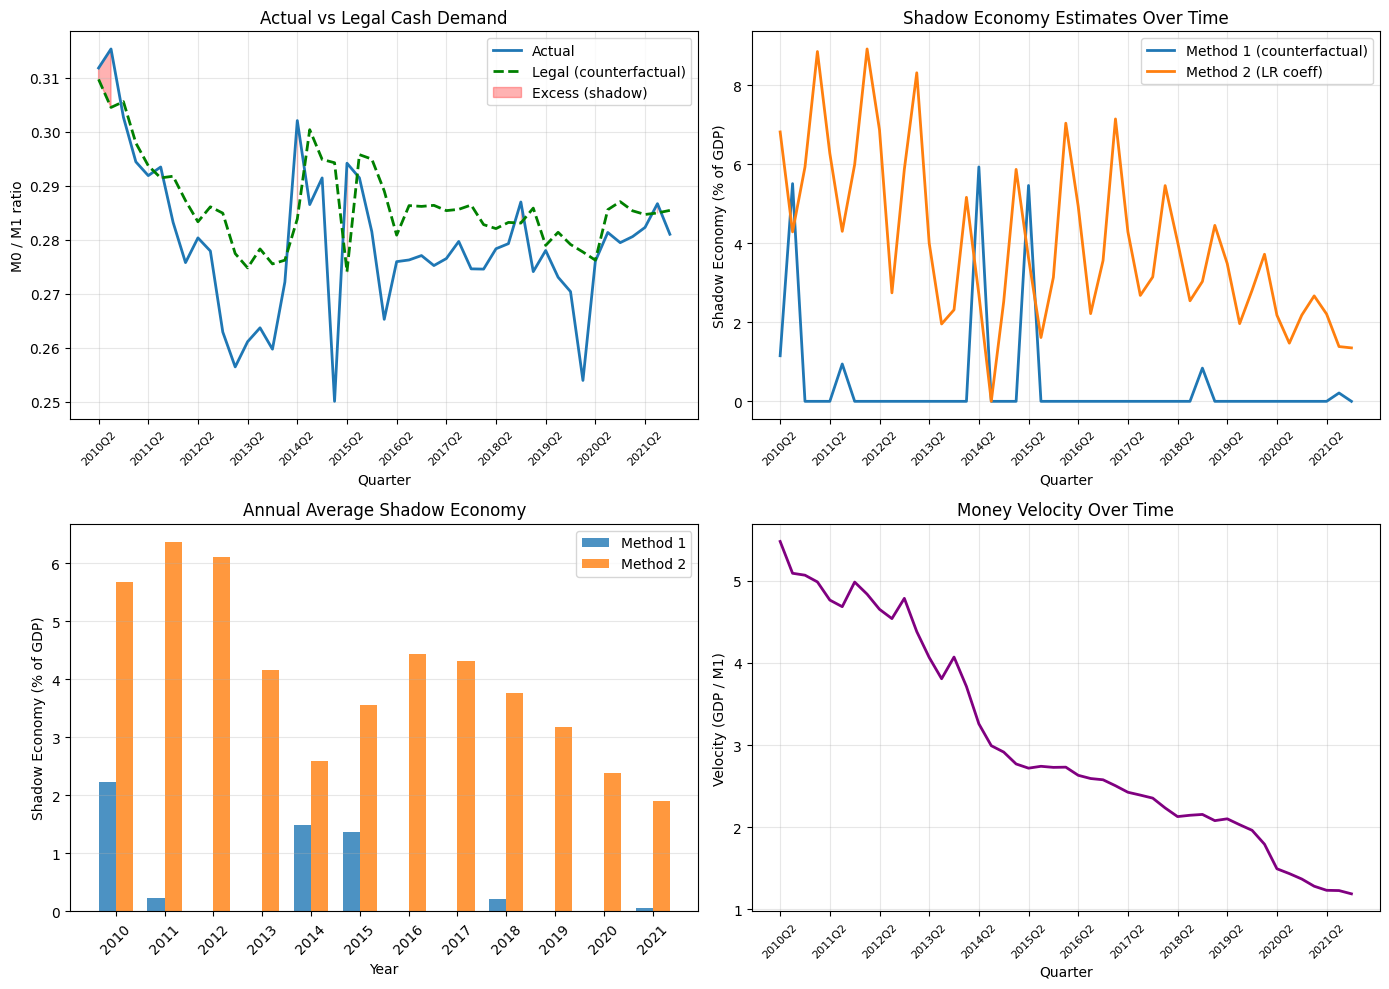

Visualization saved as 'shadow_economy_estimates_cda.png'
Results saved to 'outputs/shadow_economy_results.csv'


In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("data/final_data.csv")
df["log_gdp_per_capita"] = np.log(df["gdp_per_capita"])
df["log_interest_rate"]  = np.log(df["interest_rate_avg_q"])
df["log1p_tax_burden"]   = np.log1p(df["tax_burden"] / 100)
df["cash_demand_lag1"]   = df["cash_demand"].shift(1)

regressors = ["cash_demand_lag1", "log1p_tax_burden", "log_gdp_per_capita", "log_interest_rate"]
model_df = df[["cash_demand", "year_quarter"] + regressors].dropna()
for col in model_df.columns:
    if col != "year_quarter":
        model_df[col] = model_df[col].astype(float)

y = model_df["cash_demand"]
X = sm.add_constant(model_df[regressors])

final_model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
print(final_model.summary())

print("=" * 60)
print("SHADOW ECONOMY ESTIMATION")
print("=" * 60)

min_tax       = df["tax_burden"].min()
min_log1p_tax = np.log1p(min_tax / 100)

print(f"\nMinimum tax burden in sample: {min_tax:.2f}%")
print(f"Maximum tax burden in sample: {df['tax_burden'].max():.2f}%")
print(f"Mean tax burden:              {df['tax_burden'].mean():.2f}%")
print(f"min log(1+t):                 {min_log1p_tax:.6f}")

X_legal = model_df[regressors].copy()
X_legal["log1p_tax_burden"] = min_log1p_tax
X_legal = sm.add_constant(X_legal, has_constant="add")
X_legal = X_legal[X.columns]

legal_cash_demand = final_model.predict(X_legal)
actual_cash_demand = model_df["cash_demand"].values

excess_cash = actual_cash_demand - legal_cash_demand

print("\n" + "=" * 60)
print("CONVERSION TO SHADOW ECONOMY SIZE")
print("=" * 60)

beta_tax = final_model.params["log1p_tax_burden"]
rho      = final_model.params["cash_demand_lag1"]
lr_tax   = beta_tax / (1 - rho)

print(f"\nShort-run tax coefficient: {beta_tax:.6f}")
print(f"AR(1) coefficient (rho):   {rho:.6f}")
print(f"Long-run tax coefficient:  {lr_tax:.6f}")

m1_aligned  = df.loc[model_df.index, "deflated_M1"].values
gdp_aligned = df.loc[model_df.index, "gdp_2"].values

velocity = gdp_aligned / m1_aligned
print(f"\nVelocity of money (quarterly nominal GDP / M1):")
print(f"  Mean: {velocity.mean():.3f}")
print(f"  Min:  {velocity.min():.3f}  ({df.loc[model_df.index, 'year_quarter'].values[velocity.argmin()]})")
print(f"  Max:  {velocity.max():.3f}  ({df.loc[model_df.index, 'year_quarter'].values[velocity.argmax()]})")

m0_gdp_ratio = (actual_cash_demand * m1_aligned) / gdp_aligned
print(f"\nM0/GDP ratio (sanity check, should be ~5-25% for Ukraine):")
print(f"  Mean: {m0_gdp_ratio.mean()*100:.1f}%  Min: {m0_gdp_ratio.min()*100:.1f}%  Max: {m0_gdp_ratio.max()*100:.1f}%")

excess_cash_uah = excess_cash * m1_aligned
shadow_gdp_m1   = excess_cash_uah * velocity

shadow_method1         = excess_cash * velocity * 100
shadow_method1_clipped = np.maximum(shadow_method1, 0)

tax_gap_log    = model_df["log1p_tax_burden"].values - min_log1p_tax
excess_cash_lr = np.abs(lr_tax) * tax_gap_log
shadow_method2 = excess_cash_lr * velocity * 100 


results = pd.DataFrame({
    "year_quarter":       model_df["year_quarter"].values,
    "tax_burden":         df.loc[model_df.index, "tax_burden"].values,
    "actual_cash_demand": actual_cash_demand,
    "legal_cash_demand":  legal_cash_demand,
    "excess_cash_ratio":  excess_cash,
    "velocity":           velocity,
    "shadow_method1":     shadow_method1_clipped,
    "shadow_method2":     shadow_method2,
})

print("\n" + "-" * 75)
print("SHADOW ECONOMY ESTIMATES BY PERIOD (% of GDP)")
print("-" * 75)
print(results[["year_quarter", "tax_burden", "excess_cash_ratio",
               "velocity", "shadow_method1", "shadow_method2"]].round(3).to_string(index=False))

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

for label, col in [
    ("Method 1 — Counterfactual prediction (floored at 0)", "shadow_method1"),
    ("Method 2 — LR coefficient × log tax gap",            "shadow_method2"),
]:
    print(f"\n{label}:")
    print(f"  Mean: {results[col].mean():.2f}%")
    print(f"  Min:  {results[col].min():.2f}%")
    print(f"  Max:  {results[col].max():.2f}%")

results["year"] = results["year_quarter"].str[:4]
annual = results.groupby("year")[["shadow_method1", "shadow_method2", "velocity"]].mean()

print("\n" + "-" * 60)
print("ANNUAL AVERAGES (% of GDP)")
print("-" * 60)
print(annual.round(2).to_string())

print("\n" + "=" * 60)
print("SENSITIVITY: ALTERNATIVE TAX BASELINES")
print("=" * 60)
print(f"\n{'Baseline':>20} | {'Tax value':>10} | {'Mean SE M2 (%)':>14}")
print("-" * 52)
for label, baseline in [
    ("Min observed",   df["tax_burden"].min()),
    ("Mean - 2 SD",    df["tax_burden"].mean() - 2*df["tax_burden"].std()),
    ("Zero tax",       0.0),
]:
    bl_log = np.log1p(max(baseline, 0) / 100)
    tg     = model_df["log1p_tax_burden"].values - bl_log
    se     = (np.abs(lr_tax) * tg * velocity * 100).mean()
    print(f"{label:>20} | {baseline:>10.2f} | {se:>14.2f}%")

print("\n" + "=" * 60)
print("DIAGNOSTIC: VARIANCE & PARTIAL R²")
print("=" * 60)

print("\nCorrelation matrix:")
print(model_df[["cash_demand", "log1p_tax_burden",
                "log_gdp_per_capita", "log_interest_rate"]].corr().round(3))

X_notax  = sm.add_constant(model_df[["cash_demand_lag1", "log_gdp_per_capita", "log_interest_rate"]])
r2_notax = sm.OLS(y, X_notax).fit().rsquared
print(f"\nR² without tax:  {r2_notax:.4f}")
print(f"R² with tax:     {final_model.rsquared:.4f}")
print(f"Tax partial R²:  {final_model.rsquared - r2_notax:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
quarters = range(len(results))
tick_positions = list(range(0, len(results), 4))
tick_labels = [results["year_quarter"].iloc[i] for i in tick_positions]

ax1 = axes[0, 0]
ax1.plot(quarters, results["actual_cash_demand"], label="Actual", linewidth=2)
ax1.plot(quarters, results["legal_cash_demand"],
         label="Legal (counterfactual)", linewidth=2, linestyle="--", color="green")
ax1.fill_between(quarters,
                 results["legal_cash_demand"], results["actual_cash_demand"],
                 where=(results["actual_cash_demand"] > results["legal_cash_demand"]),
                 alpha=0.3, color="red", label="Excess (shadow)")
ax1.set_xlabel("Quarter")
ax1.set_ylabel("M0 / M1 ratio")
ax1.set_title("Actual vs Legal Cash Demand")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels, rotation=45, fontsize=8)

ax2 = axes[0, 1]
ax2.plot(quarters, results["shadow_method1"], label="Method 1 (counterfactual)", linewidth=2)
ax2.plot(quarters, results["shadow_method2"], label="Method 2 (LR coeff)", linewidth=2)
ax2.set_xlabel("Quarter")
ax2.set_ylabel("Shadow Economy (% of GDP)")
ax2.set_title("Shadow Economy Estimates Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(tick_positions)
ax2.set_xticklabels(tick_labels, rotation=45, fontsize=8)

ax3 = axes[1, 0]
x = np.arange(len(annual))
width = 0.35
ax3.bar(x - width/2, annual["shadow_method1"], width, label="Method 1", alpha=0.8)
ax3.bar(x + width/2, annual["shadow_method2"], width, label="Method 2", alpha=0.8)
ax3.set_xlabel("Year")
ax3.set_ylabel("Shadow Economy (% of GDP)")
ax3.set_title("Annual Average Shadow Economy")
ax3.set_xticks(x)
ax3.set_xticklabels(annual.index, rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

ax4 = axes[1, 1]
ax4.plot(quarters, results["velocity"], linewidth=2, color="purple")
ax4.set_xlabel("Quarter")
ax4.set_ylabel("Velocity (GDP / M1)")
ax4.set_title("Money Velocity Over Time")
ax4.grid(True, alpha=0.3)
ax4.set_xticks(tick_positions)
ax4.set_xticklabels(tick_labels, rotation=45, fontsize=8)

plt.tight_layout()
plt.savefig("outputs/shadow_economy_estimates_cda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualization saved as 'shadow_economy_estimates_cda.png'")

results.to_csv("outputs/shadow_economy_results.csv", index=False)
print("Results saved to 'outputs/shadow_economy_results.csv'")